# ORACLE-Paired: what gets generated, how big, and what each piece proves

This notebook walks the `src/oracle_paired` production pipeline end to end on a
**synthetic demo** (no Prometheus needed): a toy detector and toy photon events
stand in for Prometheus output, so every stage downstream of the photon
simulation — the NuBench-style detector response, the N/S/U intervention
strata, content matching, and provenance export — runs and is inspectable here.

Context: `docs/EXPERIMENT_DESIGN.md`. The production this demonstrates is
**Tier 2 (realism)** of the three-tier design: one seeded LeptonInjector run
replayed through ORCA and ARCA, our own §3.2 response, and per geometry the
strata below. Tier 1 (the covariance mechanism) lives in `src/noise_module/`
and is a different notebook (`noise_module_tutorial.ipynb`).

In [1]:
import sys
sys.path.insert(0, "src")
import numpy as np
import matplotlib.pyplot as plt

from oracle_paired import (
    DetectorGeometry, ResponseConfig, emulate_response,
    ModuleLoss, HitThinning, TimingJitter, GainDrift, NoiseRateScale,
    toy_population, toy_track, overlay_pileup, inject_correlated_noise,
    match_clean_controls, content_features,
    provenance_record, export_parquet,
    ProductionPlan, prometheus_config_pairs,
)
from oracle_paired.interventions import apply_interventions

geometry = DetectorGeometry.demo_grid(n_strings_side=4, oms_per_string=12)
print(f"demo detector: {geometry.n_om} OMs on {geometry.strings.size} strings")

demo detector: 192 OMs on 16 strings


## 1. The clean arm — what a "generated event" is

`toy_track` / `toy_cascade` imitate the *shape* of Prometheus output: photon
arrivals at OMs with times and a truth record. In the real production this
cell is replaced by reading Prometheus parquet; nothing after it changes.

In [2]:
clean_photons = toy_population(120, geometry, seed=42)
ev = clean_photons[0]
print(f"event 0: {ev.n_photons} photons, truth = { {k: round(v,1) if isinstance(v,float) else v for k,v in ev.truth.items()} }")

event 0: 640 photons, truth = {'energy_gev': 1765.6, 'zenith_rad': 0.3, 'azimuth_rad': 4.8, 'vertex_x': 131.7, 'vertex_y': 257.6, 'vertex_z': -66.6, 'interaction': 'numu_cc', 'topology': 'track'}


## 2. The response stage — NuBench §3.2, owned in-project

QE thinning (20%), a ≥5 µs trigger window, uniform noise photons, per-OM TTS
merging into pulses, 1 ns / 0.25 pe smearing, pulse-count cuts. NuBench never
released this stage as code; owning it matters because **every acquisition
knob (N family) lives here**. The TTS merge window length is not stated in the
NuBench paper — our 2 ns default is a declared assumption, recorded in every
provenance record.

photons in : 640
pulses out : 99  (charge 125.3 pe, window 5.0 us, passed cuts: True)


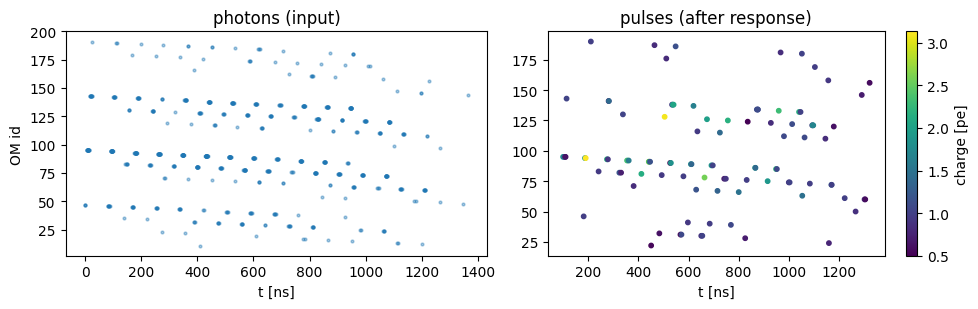

In [3]:
cfg = ResponseConfig(noise_rate_per_om_us=0.001)
pulses = emulate_response(ev, geometry, cfg, rng=7)
print(f"photons in : {ev.n_photons}")
print(f"pulses out : {pulses.n_pulses}  (charge {pulses.total_charge_pe:.1f} pe, "
      f"window {pulses.window_ns/1e3:.1f} us, passed cuts: {pulses.passed_cuts})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].scatter(ev.t_ns, ev.om_id, s=4, alpha=0.4)
ax[0].set(title="photons (input)", xlabel="t [ns]", ylabel="OM id")
sc = ax[1].scatter(pulses.t_ns, pulses.om_id, s=10, c=pulses.charge_pe, cmap="viridis")
ax[1].set(title="pulses (after response)", xlabel="t [ns]")
plt.colorbar(sc, ax=ax[1], label="charge [pe]")
plt.tight_layout(); plt.show()

## 3. The N families — *what changed, to check what*

Each intervention changes exactly one acquisition-contract term. The table
printed below is the executable version of the claim map: the observable that
moves is the fingerprint the monitor may see; the *contract term* that moved is
what an N-attribution must recover. Test coverage:
`tests/test_interventions.py` asserts each row's predicted change.

| Cell | What changed | Observable that moves | Checks |
|---|---|---|---|
| N1 `ModuleLoss` | OMs removed (opt. whole strings) | multiplicity ↓, spatial holes | C1/C2 vs S at matched content |
| N2 `HitThinning` | photons dropped | multiplicity ↓, *no* spatial holes | N1-vs-N2 separability |
| N3 `TimingJitter` | time smear 1 ns → σ | time residuals ↑ | temporal-feature monitors |
| N4 `GainDrift` | per-string charge scale | charge pattern by string | calibration-drift attribution |
| N5 `NoiseRateScale` | uniform noise rate ↑ | noise fraction ↑ | rate-based vs shape-based alarms |

In [4]:
def observables(p):
    nf = 1.0 - float(np.mean(p.signal_fraction)) if p.n_pulses else 0.0
    return dict(n_pulses=p.n_pulses, charge=round(p.total_charge_pe, 1),
                spread=round(p.time_spread_ns, 1), noise_frac=round(nf, 3))

interventions = {
    "clean": [],
    "N1 module_loss 25%": [ModuleLoss(fraction=0.25, seed=1)],
    "N1b string_loss 25%": [ModuleLoss(fraction=0.25, by_string=True, seed=1)],
    "N2 hit_thinning 25%": [HitThinning(p=0.25, seed=2)],
    "N3 jitter 30ns": [TimingJitter(sigma_ns=30.0)],
    "N4 gain_drift 0.5": [GainDrift(sigma=0.5, seed=3)],
    "N5 noise x30": [NoiseRateScale(factor=30.0)],
}
big = toy_track(0, geometry, energy_gev=5e3, rng=11)
rows = []
for name, ivs in interventions.items():
    ph, cfg2, log = apply_interventions(big, geometry, cfg, ivs)
    out = emulate_response(ph, geometry, cfg2, rng=99)
    for iv in ivs:
        out = iv.apply_pulses(out, geometry)
    rows.append((name, observables(out)))
w = max(len(n) for n, _ in rows)
print(f"{'cell':<{w}}  n_pulses  charge   spread  noise_frac")
for name, o in rows:
    print(f"{name:<{w}}  {o['n_pulses']:>8}  {o['charge']:>6}  {o['spread']:>7}  {o['noise_frac']:>9}")

cell                 n_pulses  charge   spread  noise_frac
clean                     189   316.9   1480.9      0.005
N1 module_loss 25%        138   223.7   1382.5        0.0
N1b string_loss 25%       139   237.8   1492.2      0.022
N2 hit_thinning 25%       151   228.6   1515.3      0.007
N3 jitter 30ns            189   316.9   1508.2      0.005
N4 gain_drift 0.5         189   423.7   1480.9      0.005
N5 noise x30              221   354.9   1798.4      0.149


## 4. Content matching — the audit P1.1 fix

Module loss *manufactures* low-multiplicity events, which are exactly the S
strata. So every N event gets a **clean twin** with the same observed content
(nearest clean neighbour in multiplicity, charge, time spread; standardized,
calipered, without replacement). Attribution evaluated on matched cells cannot
be fingerprint recognition of the corruption operator. This is why the
production overproduces `clean` by 3–5×: the matching pool must be deep enough
that every corrupted event finds a twin inside the caliper.

matched 30/30 treated events (median standardized distance 0.15); 0 unmatched -> excluded, never force-matched


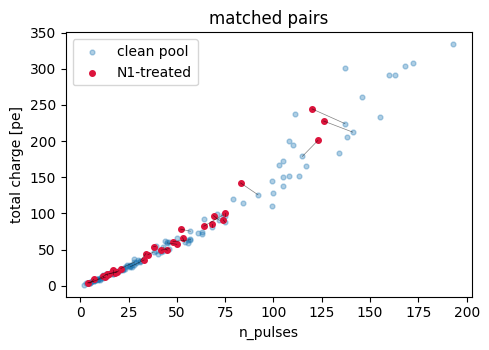

In [5]:
clean_p = [emulate_response(e, geometry, cfg, rng=100 + e.event_id) for e in clean_photons]
treated_ph = clean_photons[:30]
treated_p = []
for e in treated_ph:
    ph2, cfg2, _ = apply_interventions(e, geometry, cfg, [ModuleLoss(fraction=0.3, seed=5)])
    out = emulate_response(ph2, geometry, cfg2, rng=100 + e.event_id)
    out = ModuleLoss(fraction=0.3, seed=5).apply_pulses(out, geometry)
    treated_p.append(out)

res = match_clean_controls(treated_p, clean_p, caliper=1.5)
print(f"matched {res.n_matched}/{len(treated_p)} treated events "
      f"(median standardized distance {np.median(res.distance):.2f}); "
      f"{res.unmatched.size} unmatched -> excluded, never force-matched")

Xt, Xc = content_features(treated_p), content_features(clean_p)
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(Xc[:, 0], Xc[:, 1], s=12, alpha=0.35, label="clean pool")
ax.scatter(Xt[:, 0], Xt[:, 1], s=16, color="crimson", label="N1-treated")
for ti, ci in zip(res.treated_index, res.control_index):
    ax.plot([Xt[ti, 0], Xc[ci, 0]], [Xt[ti, 1], Xc[ci, 1]], "k-", lw=0.5, alpha=0.5)
ax.set(xlabel="n_pulses", ylabel="total charge [pe]", title="matched pairs")
ax.legend(); plt.tight_layout(); plt.show()

## 5. U families — what the monitor must *refuse* to classify

Undeclared families for the abstention endpoint (C3). Built here: pile-up
(U3) and spatially correlated noise (U4 — bursts on OM *neighbourhoods*,
which no declared N family produces; N5's noise is uniform and independent).
τ double-bang (U1) and through-going muons (U2) are injection-level and come
from their own Prometheus run plans (`tau_plan`, `throughgoing_muon_plan`).

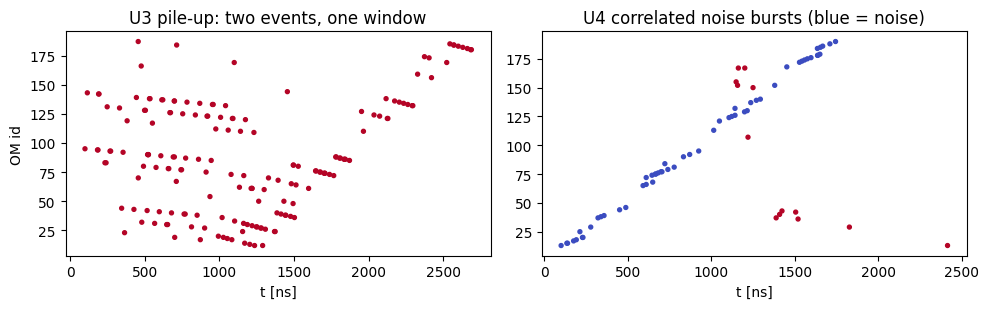

In [6]:
u3 = overlay_pileup(clean_photons[0], clean_photons[1], offset_ns=800.0, event_id=9001)
u4 = inject_correlated_noise(clean_photons[2], geometry, rng=3)
p3 = emulate_response(u3, geometry, cfg, rng=1)
p4 = emulate_response(u4, geometry, cfg, rng=2)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].scatter(p3.t_ns, p3.om_id, s=8, c=p3.signal_fraction, cmap="coolwarm_r")
ax[0].set(title="U3 pile-up: two events, one window", xlabel="t [ns]", ylabel="OM id")
ax[1].scatter(p4.t_ns, p4.om_id, s=8, c=p4.signal_fraction, cmap="coolwarm_r")
ax[1].set(title="U4 correlated noise bursts (blue = noise)", xlabel="t [ns]")
plt.tight_layout(); plt.show()

## 6. The Prometheus run plans — the pairing mechanism itself

The whole geometry axis is this diff: two configs, identical seed and
injection file, `inject=False` on the second, different `geo_file`. That is
what "same event, different geometry" means operationally
(`tests/test_configs.py` asserts nothing else differs).

In [7]:
import json
plan = ProductionPlan()
cfg_orca, cfg_arca = prometheus_config_pairs(plan)
print("ORCA :", json.dumps(cfg_orca["detector"]), "inject:", cfg_orca["injection"]["lepton_injector"]["inject"])
print("ARCA :", json.dumps(cfg_arca["detector"]), "inject:", cfg_arca["injection"]["lepton_injector"]["inject"])
print("shared injection file:", cfg_arca["injection"]["lepton_injector"]["paths"]["injection_file"])
print("shared seed:", cfg_arca["run"]["random_state_seed"])

ORCA : {"geo_file": "orca.geo"} inject: True
ARCA : {"geo_file": "arca.geo"} inject: False
shared injection file: injection/paired_injection.h5
shared seed: 20260831


## 7. Export — provenance the released NuBench sets don't have

Two Parquet tables per geometry, readable by GraphNeT's Dataset classes so the
released DynEdge checkpoint runs on them unchanged. The truth table carries
`injection_id` (the cross-geometry pairing key), the stratum label, and the
exact intervention parameters as JSON.

In [8]:
records = [provenance_record(p, injection_id=p.event_id, geometry_name="demo",
                             stratum="clean", interventions=[], response_seed=100)
           for p in clean_p[:20]]
p_path, t_path = export_parquet(clean_p[:20], geometry, records, "demo_out")
import pandas as pd
dft = pd.read_parquet(t_path)
dfp = pd.read_parquet(p_path)
print("pulse table:", dfp.shape, "->", list(dfp.columns))
print("truth table:", dft.shape)
dft.head(4)

pulse table: (1452, 9) -> ['event_no', 'om_id', 'dom_x', 'dom_y', 'dom_z', 'string_id', 'dom_time', 'charge', 'signal_fraction']
truth table: (20, 19)


,event_no,injection_id,geometry,stratum,intervention_json,response_seed,passed_cuts,n_pulses,total_charge,time_spread,window_ns,truth_energy_gev,truth_zenith_rad,truth_azimuth_rad,truth_vertex_x,truth_vertex_y,truth_vertex_z,truth_interaction,truth_topology
0,0,0,demo,clean,[],100,True,84,114.534192,885.849645,5000.0,1765.558457,0.313550,4.782382,131.663532,257.579376,-66.579034,numu_cc,track
1,1,1,demo,clean,[],100,True,92,125.754712,1086.476699,5000.0,1621.993425,1.226117,0.330345,77.226709,248.036965,-15.948931,numu_cc,track
2,2,2,demo,clean,[],100,True,54,60.093248,1391.200503,5000.0,859.624778,1.780193,0.259200,203.493183,224.019514,-106.353609,numu_cc,track
3,3,3,demo,clean,[],100,True,74,98.059712,821.873430,5000.0,1193.339511,2.724042,4.532494,283.184138,128.038686,-21.756831,numu_cc,track


## 8. The full production: how big, and what each stratum proves

Per geometry, from **one** injection (numbers per `docs/EXPERIMENT_DESIGN.md`;
the 120k total is *provisional pending the D6 power analysis*, which runs on
the Tier-1 simulator). Rough size: at NuBench-like pulse multiplicities
(~10²–10³ pulses/event, ~40 B/pulse row) the demo measures the bytes/pulse
below and scales.

| Stratum | Share of injection | Job |
|---|---|---|
| `clean` (overproduced 3–5×) | ~55% | reference arm + matching pool |
| N1–N5 × severities | ~25% | acquisition-contract violations (C1, C2) |
| S1–S5 | ~10% | supported-but-rare physics (C2's other arm) |
| U1–U4 | ~10% | abstention (C3) |

**What the dataset as a whole proves:** C1 detection at 1% FAB on a frozen
public model; C2 N-vs-S attribution *on content-matched cells*; C3 abstention
on U families; the observational half of C4 (conditional-on-alarm AUROC on
angular error); and E5 — the out-of-sample test of monitor-failure predictions
pre-registered on Tier 1. Cost: ~1–10 CPU-s/event/geometry (profiled at
1–100 TeV — re-profile on a 1k pilot before queueing) → order 300 CPU-hours
for 120k × 2 geometries, embarrassingly parallel.

In [9]:
import os
bytes_per_pulse = os.path.getsize(p_path) / max(1, dfp.shape[0])
pulses_per_event = dfp.shape[0] / 20
for n_events, label in [(120_000, "one geometry"), (240_000, "both geometries")]:
    est = n_events * pulses_per_event * bytes_per_pulse / 1e9
    print(f"{label:>16}: ~{est:.1f} GB at demo multiplicity "
          f"({pulses_per_event:.0f} pulses/event, {bytes_per_pulse:.0f} B/pulse)")
print("NuBench-scale events are 10-100x more pulses -> plan for tens to hundreds of GB;")
print("this is why the release ships per-stratum parquet shards, not one file.")

    one geometry: ~0.2 GB at demo multiplicity (73 pulses/event, 26 B/pulse)
 both geometries: ~0.4 GB at demo multiplicity (73 pulses/event, 26 B/pulse)
NuBench-scale events are 10-100x more pulses -> plan for tens to hundreds of GB;
this is why the release ships per-stratum parquet shards, not one file.


## 9. What still needs Prometheus

Everything above ran without it. The real production needs: (1) Prometheus +
LeptonInjector installed on the cluster, run from the two emitted configs;
(2) a reader from Prometheus parquet to `EventPhotons` (replacing `toy.py`);
(3) the D6 power analysis to freeze per-cell counts; (4) a 1k-event pilot to
re-profile CPU cost. The response stage, interventions, strata, matching and
export — the parts that had to be implemented ourselves — are done and tested
(`22 passed`).